In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split


warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


In [3]:
pd.set_option('display.max_columns', None)

df = pd.read_csv("group_26_train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 35)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2018-03-30 17:32:46,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2
1,Source1,2022-07-27 13:42:00,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-06 13:00:30,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2021-09-07 21:50:00,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
4,Source2,2019-05-23 20:52:35,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,3


In [4]:
df.sample(5)

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
61327,Source1,2021-11-08 15:36:17,29.596317,-95.213281,29.597122,-95.212439,0.075,Sagedowne Ln,Houston,Harris,TX,77089-4622,KEFD,72.0,72.0,30.17,10.0,E,12.0,NaN,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
68611,Source2,2017-04-28 13:51:50,29.661087,-95.288963,NaN,NaN,0.010,Morley St,Houston,Harris,TX,77061,KHOU,84.9,NaN,29.70,10.0,SSE,18.4,NaN,Scattered Clouds,False,False,False,False,False,True,False,False,False,Day,Day,Day,Day,2
85486,Source1,2021-06-02 01:57:00,36.327612,-119.437651,36.327644,-119.439431,0.099,Hanford Expy,Visalia,Tulare,CA,93291,KVIS,77.0,77.0,29.50,10.0,NNW,6.0,0.0,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
73554,Source1,2017-07-12 12:40:01,36.288583,-86.724816,36.288583,-86.724816,0.000,I-65 N,Madison,Davidson,TN,37115,KBNA,91.0,NaN,30.11,10.0,SSW,8.1,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
26156,Source1,2022-09-25 01:57:25,47.760987,-91.647994,47.755823,-91.648475,0.357,Highway 1,Isabella,Lake,MN,55607,KBFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   f1      100000 non-null  str    
 1   f2      100000 non-null  str    
 2   f3      100000 non-null  float64
 3   f4      100000 non-null  float64
 4   f5      55744 non-null   float64
 5   f6      55744 non-null   float64
 6   f7      100000 non-null  float64
 7   f8      99844 non-null   str    
 8   f9      99998 non-null   str    
 9   f10     100000 non-null  str    
 10  f11     100000 non-null  str    
 11  f12     99974 non-null   str    
 12  f13     99716 non-null   str    
 13  f14     97926 non-null   float64
 14  f15     74018 non-null   float64
 15  f16     98212 non-null   float64
 16  f17     97793 non-null   float64
 17  f18     97773 non-null   str    
 18  f19     92625 non-null   float64
 19  f20     71369 non-null   float64
 20  f21     97818 non-null   str    
 21  f22     100000 non-nul

In [6]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 11
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20']

Categorical columns: 14
['f1', 'f2', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'f31', 'f32', 'f33', 'f34']

Boolean columns: 9
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']


In [7]:
df['f2'] = pd.to_datetime(df['f2'], format='mixed', errors='coerce')

df['hour'] = df['f2'].dt.hour
df['dayofweek'] = df['f2'].dt.dayofweek
df['month'] = df['f2'].dt.month
df['year'] = df['f2'].dt.year

weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df['weekday_name'] = df['dayofweek'].map(weekday_map)
df['month_name'] = df['month'].map(month_map)

print(f"Null values in 'hour' column: {df['hour'].isnull().sum()}")

display(df[['f2', 'year', 'month', 'month_name', 'dayofweek', 'weekday_name', 'hour']].head())

df = df.drop(columns=['f2'])


Null values in 'hour' column: 0


,f2,year,month,month_name,dayofweek,weekday_name,hour
0,2018-03-30 17:32:46,2018,3,Mar,4,Fri,17
1,2022-07-27 13:42:00,2022,7,Jul,2,Wed,13
2,2022-06-06 13:00:30,2022,6,Jun,0,Mon,13
3,2021-09-07 21:50:00,2021,9,Sep,1,Tue,21
4,2019-05-23 20:52:35,2019,5,May,3,Thu,20


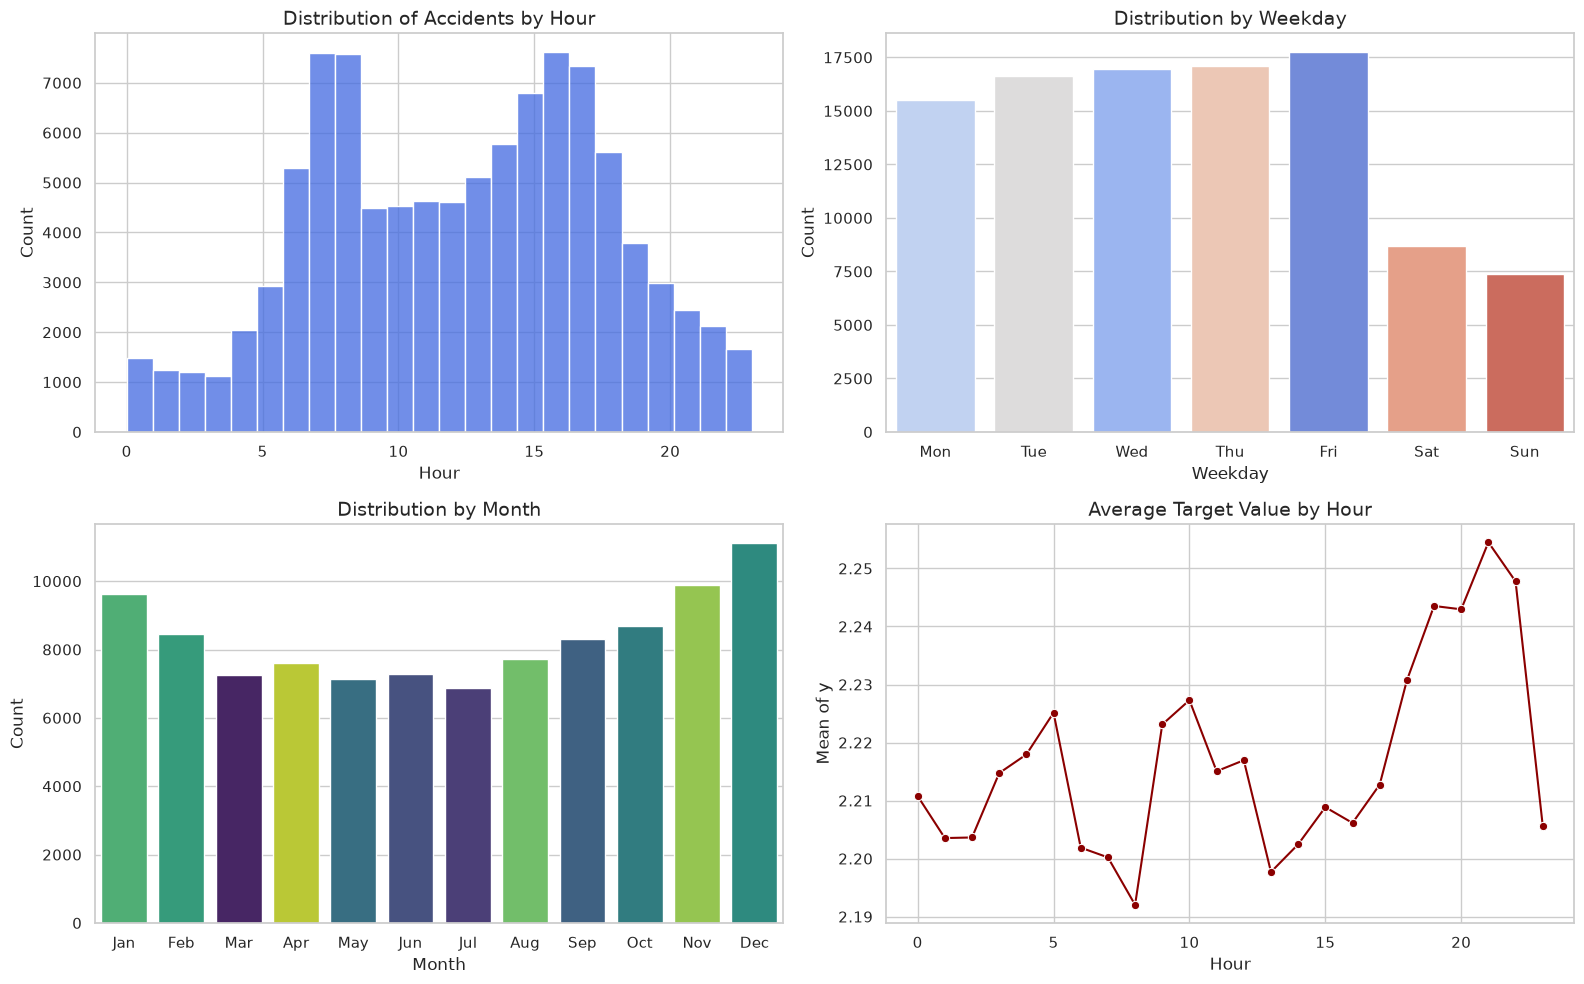

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(
    df['hour'].dropna(),
    bins=24,
    kde=False,
    ax=axes[0, 0],
    color='royalblue'
)
axes[0, 0].set_title('Distribution of Accidents by Hour')
axes[0, 0].set_xlabel('Hour')

sns.countplot(
    data=df,
    x='weekday_name',
    order=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    ax=axes[0, 1],
    palette='coolwarm',
    hue='weekday_name',
    legend=False
)
axes[0, 1].set_title('Distribution by Weekday')
axes[0, 1].set_xlabel('Weekday')
axes[0, 1].set_ylabel('Count')

sns.countplot(
    data=df,
    x='month_name',
    order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    ax=axes[1, 0],
    palette='viridis',
    hue='month_name',
    legend=False
)
axes[1, 0].set_title('Distribution by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Count')

hour_target = df.groupby('hour')['y'].mean()

sns.lineplot(
    x=hour_target.index,
    y=hour_target.values,
    marker='o',
    ax=axes[1, 1],
    color='darkred'
)
axes[1, 1].set_title('Average Target Value by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Mean of y')

plt.tight_layout()
plt.show()

df.drop(columns=['weekday_name', 'month_name'], inplace=True)


In [9]:
day_night_cols = ['f31','f32', 'f33', 'f34']

for col in day_night_cols:
    df[col] = df[col].map({'Day': False, 'Night': True}).astype(bool)


In [10]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 15
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20', 'hour', 'dayofweek', 'month', 'year']

Categorical columns: 9
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,missing_count,missing_percent
f6,44256,44.256
f5,44256,44.256
f20,28631,28.631
f15,25982,25.982
f19,7375,7.375
f18,2227,2.227
f17,2207,2.207
f21,2182,2.182
f14,2074,2.074
f16,1788,1.788


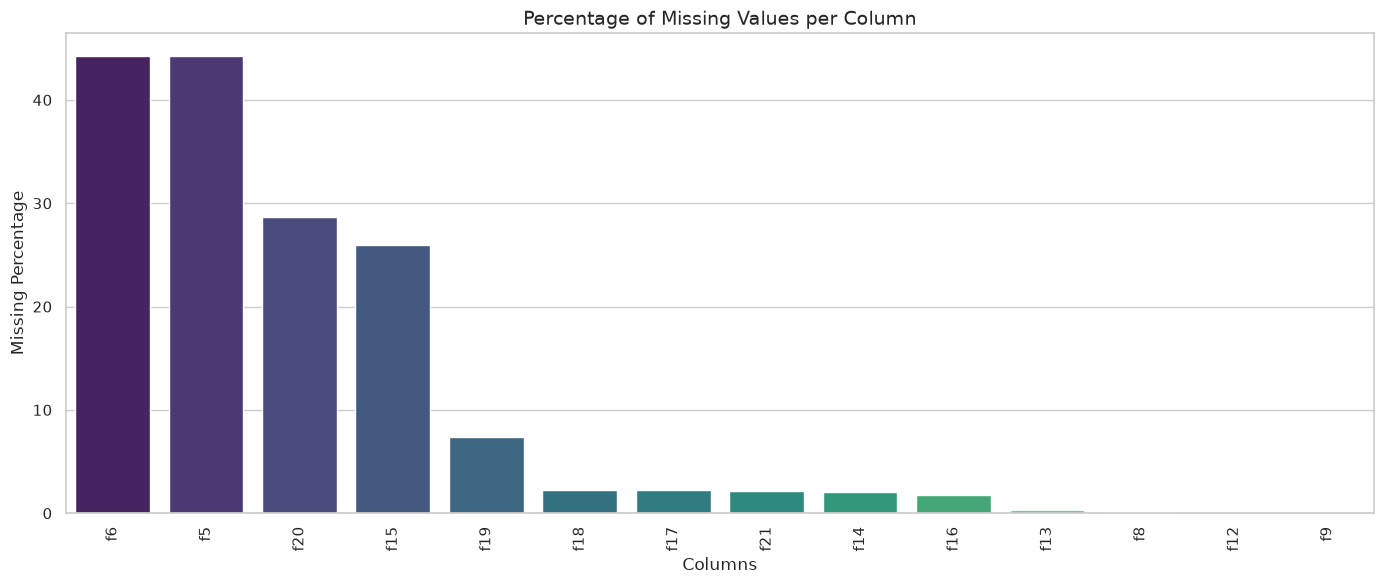

In [11]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)

plt.figure(figsize=(14,6))
sns.barplot(x=missing_df.index, y=missing_df['missing_percent'], palette='viridis')

plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


In [12]:
desc_stats = df[numeric_cols].describe().T

desc_stats["range"] = desc_stats["max"] - desc_stats["min"]

desc_stats


,count,mean,std,min,25%,50%,75%,max,range
f3,100000.0,36.188088,5.081102,24.599331,33.368866,35.801849,40.071363,48.974396,24.375065
f4,100000.0,-94.789912,17.391180,-124.493149,-117.237465,-87.905347,-80.365911,-68.370040,56.123109
f5,55744.0,36.265218,5.263918,24.669550,33.461822,36.162364,40.152109,48.972835,24.303285
f6,55744.0,-95.838090,18.076242,-124.450182,-117.739344,-88.468429,-80.266970,-68.358910,56.091272
f7,100000.0,0.566265,1.759484,0.000000,0.000000,0.027000,0.465000,112.903000,112.903000
f14,97926.0,61.687509,19.005531,-37.000000,49.000000,64.000000,76.000000,122.000000,159.000000
f15,74018.0,58.218894,22.399464,-52.200000,43.000000,62.000000,75.000000,114.000000,166.200000
f16,98212.0,29.532370,1.019610,19.750000,29.370000,29.850000,30.030000,58.390000,38.640000
f17,97793.0,9.085640,2.662043,0.000000,10.000000,10.000000,10.000000,80.000000,80.000000
f19,92625.0,7.674199,5.877039,0.000000,4.600000,7.000000,10.400000,812.000000,812.000000


In [13]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)

skewness


f20          77.328223
f19          28.242046
f7           13.479845
f17           1.833843
dayofweek     0.187488
f3           -0.055770
month        -0.088293
hour         -0.128699
f5           -0.145489
f6           -0.352678
year         -0.433728
f4           -0.472218
f14          -0.505407
f15          -0.660922
f16          -3.350646
dtype: float64

In [14]:
outlier_counts = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier Count"])

outlier_df.sort_values("Outlier Count", ascending=False)


,Outlier Count
f17,19203
f7,12529
f20,6907
f16,5836
f19,2708
f14,625
f15,558
f6,0
f3,0
f4,0


,unique_values
f3,90725
f4,90686
f6,51577
f5,51573
f12,36879
f8,32428
f9,6406
f7,6177
f13,1616
f10,1303


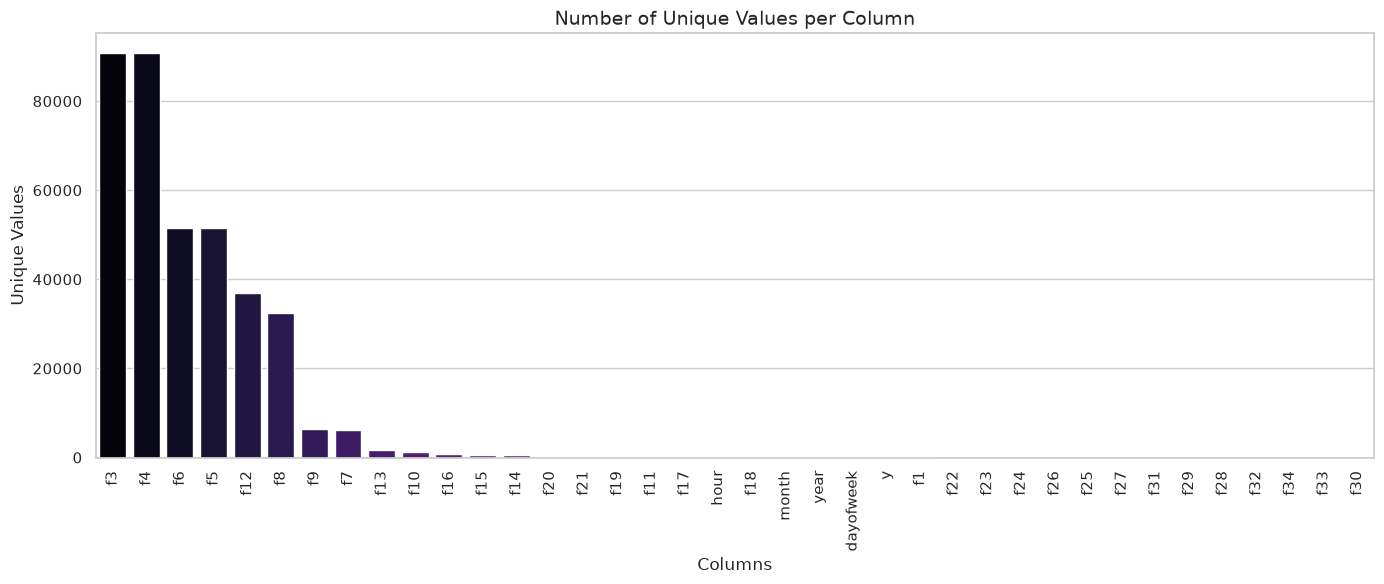

In [16]:
unique_counts = df.nunique().sort_values(ascending=False)

display(unique_counts.to_frame(name='unique_values'))

plt.figure(figsize=(14,6))
sns.barplot(x=unique_counts.index, y=unique_counts.values, palette='magma')

plt.xticks(rotation=90)
plt.title('Number of Unique Values per Column')
plt.ylabel('Unique Values')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


In [15]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print("Constant columns:")
print(constant_cols)


Constant columns:
['f30']


In [16]:
near_constant = []

for col in df.columns:
    
    top_freq = df[col].value_counts(normalize=True).values[0]
    
    if top_freq > 0.95:
        near_constant.append(col)

print("Near constant features:")
print(near_constant)


Near constant features:
['f22', 'f23', 'f25', 'f26', 'f27', 'f28', 'f30']


In [17]:
near_constant = [c for c in ['f22', 'f23', 'f25', 'f26', 'f27', 'f28', 'f30'] if c in df.columns]

print("Correlation analysis (near-constant vs y):")
print("-" * 40)

correlations = {}
for col in near_constant:
    corr_value = df[col].corr(df['y'])
    correlations[col] = abs(corr_value)
    print(f"Feature: {col} | Abs Correlation: {abs(corr_value):.6f}")

print("-" * 40)
print("Recommendation:")
for col, val in correlations.items():
    status = "DROP" if val < 0.01 else "KEEP/CAUTION"
    print(f"{col}: {status} (Value: {val:.6f})")


Correlation analysis (near-constant vs y):
----------------------------------------
Feature: f22 | Abs Correlation: 0.036326
Feature: f23 | Abs Correlation: 0.002883
Feature: f25 | Abs Correlation: 0.015837
Feature: f26 | Abs Correlation: 0.001339
Feature: f27 | Abs Correlation: 0.045029
Feature: f28 | Abs Correlation: 0.003331
Feature: f30 | Abs Correlation: nan
----------------------------------------
Recommendation:
f22: KEEP/CAUTION (Value: 0.036326)
f23: DROP (Value: 0.002883)
f25: KEEP/CAUTION (Value: 0.015837)
f26: DROP (Value: 0.001339)
f27: KEEP/CAUTION (Value: 0.045029)
f28: DROP (Value: 0.003331)
f30: KEEP/CAUTION (Value: nan)


,count,percent
y,,
1,826,0.856695
2,76739,79.590736
3,16337,16.944107
4,2515,2.608461


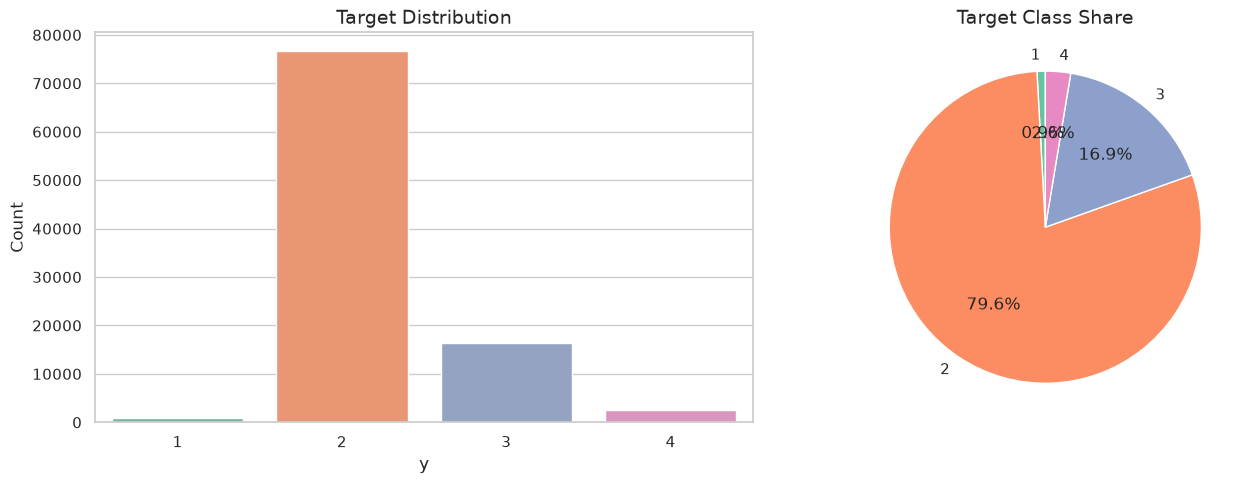

In [51]:
target_counts = df['y'].value_counts().sort_index()
target_percent = df['y'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'count': target_counts,
    'percent': target_percent
}))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='y', ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Count')

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)

axes[1].set_title('Target Class Share')

plt.tight_layout()
plt.show()


In [19]:
duplicate_mask = df.duplicated()

duplicate_rows = df[duplicate_mask]

print("Number of duplicate rows:", duplicate_rows.shape[0])
duplicate_rows


Number of duplicate rows: 136


,f1,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y,hour,dayofweek,month,year
9445,Source1,37.680321,-97.171329,37.679346,-97.166697,0.262,S 143rd St E,Wichita,Sedgwick,KS,67230,KAAO,73.0,73.0,28.25,10.0,W,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,4,4,2022
9611,Source1,32.933505,-80.046250,32.935199,-80.046050,0.118,Dunlap St,Charleston,Charleston,SC,29406-4152,KCHS,76.0,76.0,30.02,10.0,NNE,6.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,4,9,2021
12548,Source1,34.518024,-111.989726,34.510744,-111.995056,0.587,Arizona Veterans Highway,Dewey,Yavapai,AZ,86327,KPRC,59.0,59.0,25.00,10.0,VAR,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,2,10,5,4,2022
14726,Source1,34.103290,-117.535976,34.082360,-117.544936,1.534,I-15,Rancho Cucamonga,San Bernardino,CA,91739,KONT,77.0,77.0,28.85,10.0,SW,8.0,0.00,Fair,False,False,False,False,False,False,False,False,False,True,True,False,False,2,20,4,6,2021
15383,Source1,28.019455,-82.758499,28.019455,-82.758499,0.000,Main St,Dunedin,Pinellas,FL,34698-4775,KPIE,88.0,NaN,29.92,10.0,Calm,NaN,NaN,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,2,16,1,9,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98310,Source1,42.710515,-78.908829,42.707483,-78.913234,0.306,I-90 W,Lake View,Erie,NY,14085,KBUF,54.0,54.0,29.13,10.0,WNW,17.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,2,5,5,6,2022
98377,Source1,39.633747,-78.908926,39.635257,-78.837456,3.804,National Fwy,Frostburg,Allegany,MD,21532,KCBE,33.0,29.0,29.24,4.0,SW,5.0,0.01,Light Snow,False,False,False,False,False,False,False,False,False,False,False,False,False,2,16,0,4,2022
98431,Source1,29.902092,-97.903965,29.926282,-97.890895,1.846,I-35 N,San Marcos,Hays,TX,78666,KHYI,47.0,44.0,29.41,10.0,SSW,6.0,0.00,Fair,False,False,True,False,False,False,False,False,False,True,True,True,True,2,22,6,1,2021
98442,Source1,36.150499,-86.856476,36.151166,-86.857719,0.083,Charlotte Pike,Nashville,Davidson,TN,37209-3210,KBNA,83.0,83.0,29.39,10.0,VAR,6.0,0.00,Partly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,2,14,0,5,2022


In [20]:
zero_counts = (df[numeric_cols] == 0).sum().sort_values(ascending=False)

zero_counts


f20          64462
f7           43052
dayofweek    15512
f19          12433
hour          1485
f17            103
f15             53
f14             30
f3               0
f4               0
f5               0
f6               0
f16              0
month            0
year             0
dtype: int64

f10: 1303
f11: 49
f12: 36879


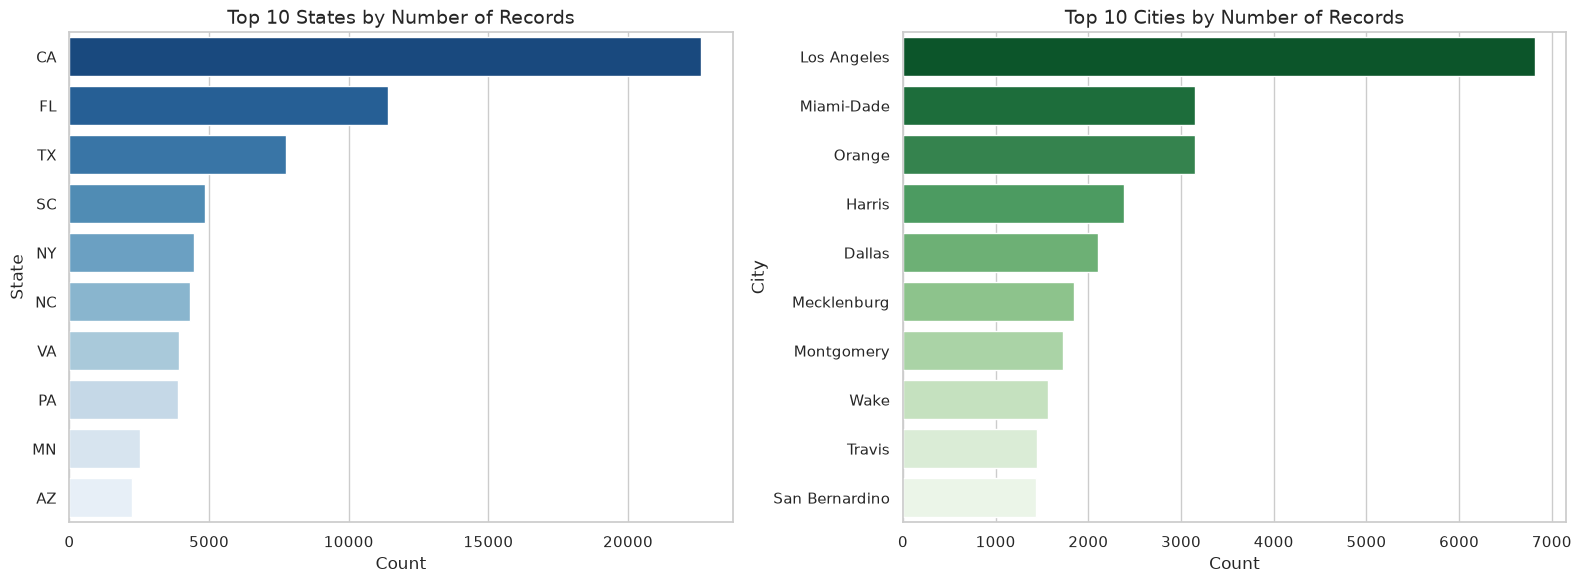

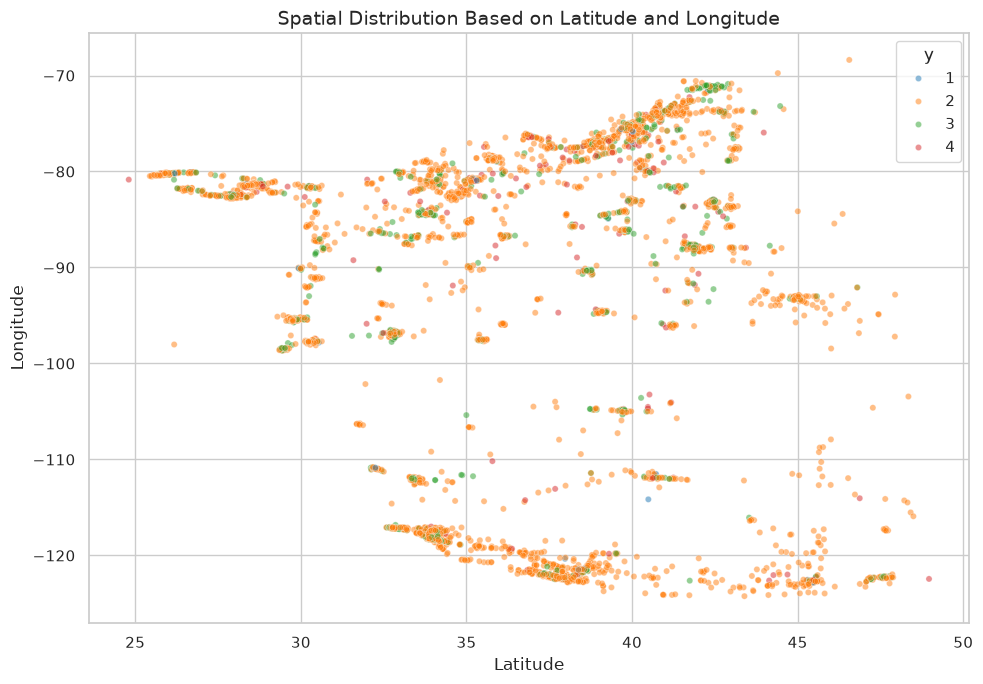

In [21]:
for col in ['f10', 'f11', 'f12']:
    print(f'{col}:', df[col].nunique(dropna=True))

state_counts = df['f11'].value_counts().head(10)
city_counts = df['f10'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 States by Number of Records')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('State')

sns.barplot(x=city_counts.values, y=city_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Cities by Number of Records')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x='f3', y='f4', hue='y', palette='tab10', alpha=0.5, s=20)
plt.title('Spatial Distribution Based on Latitude and Longitude')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.tight_layout()
plt.show()


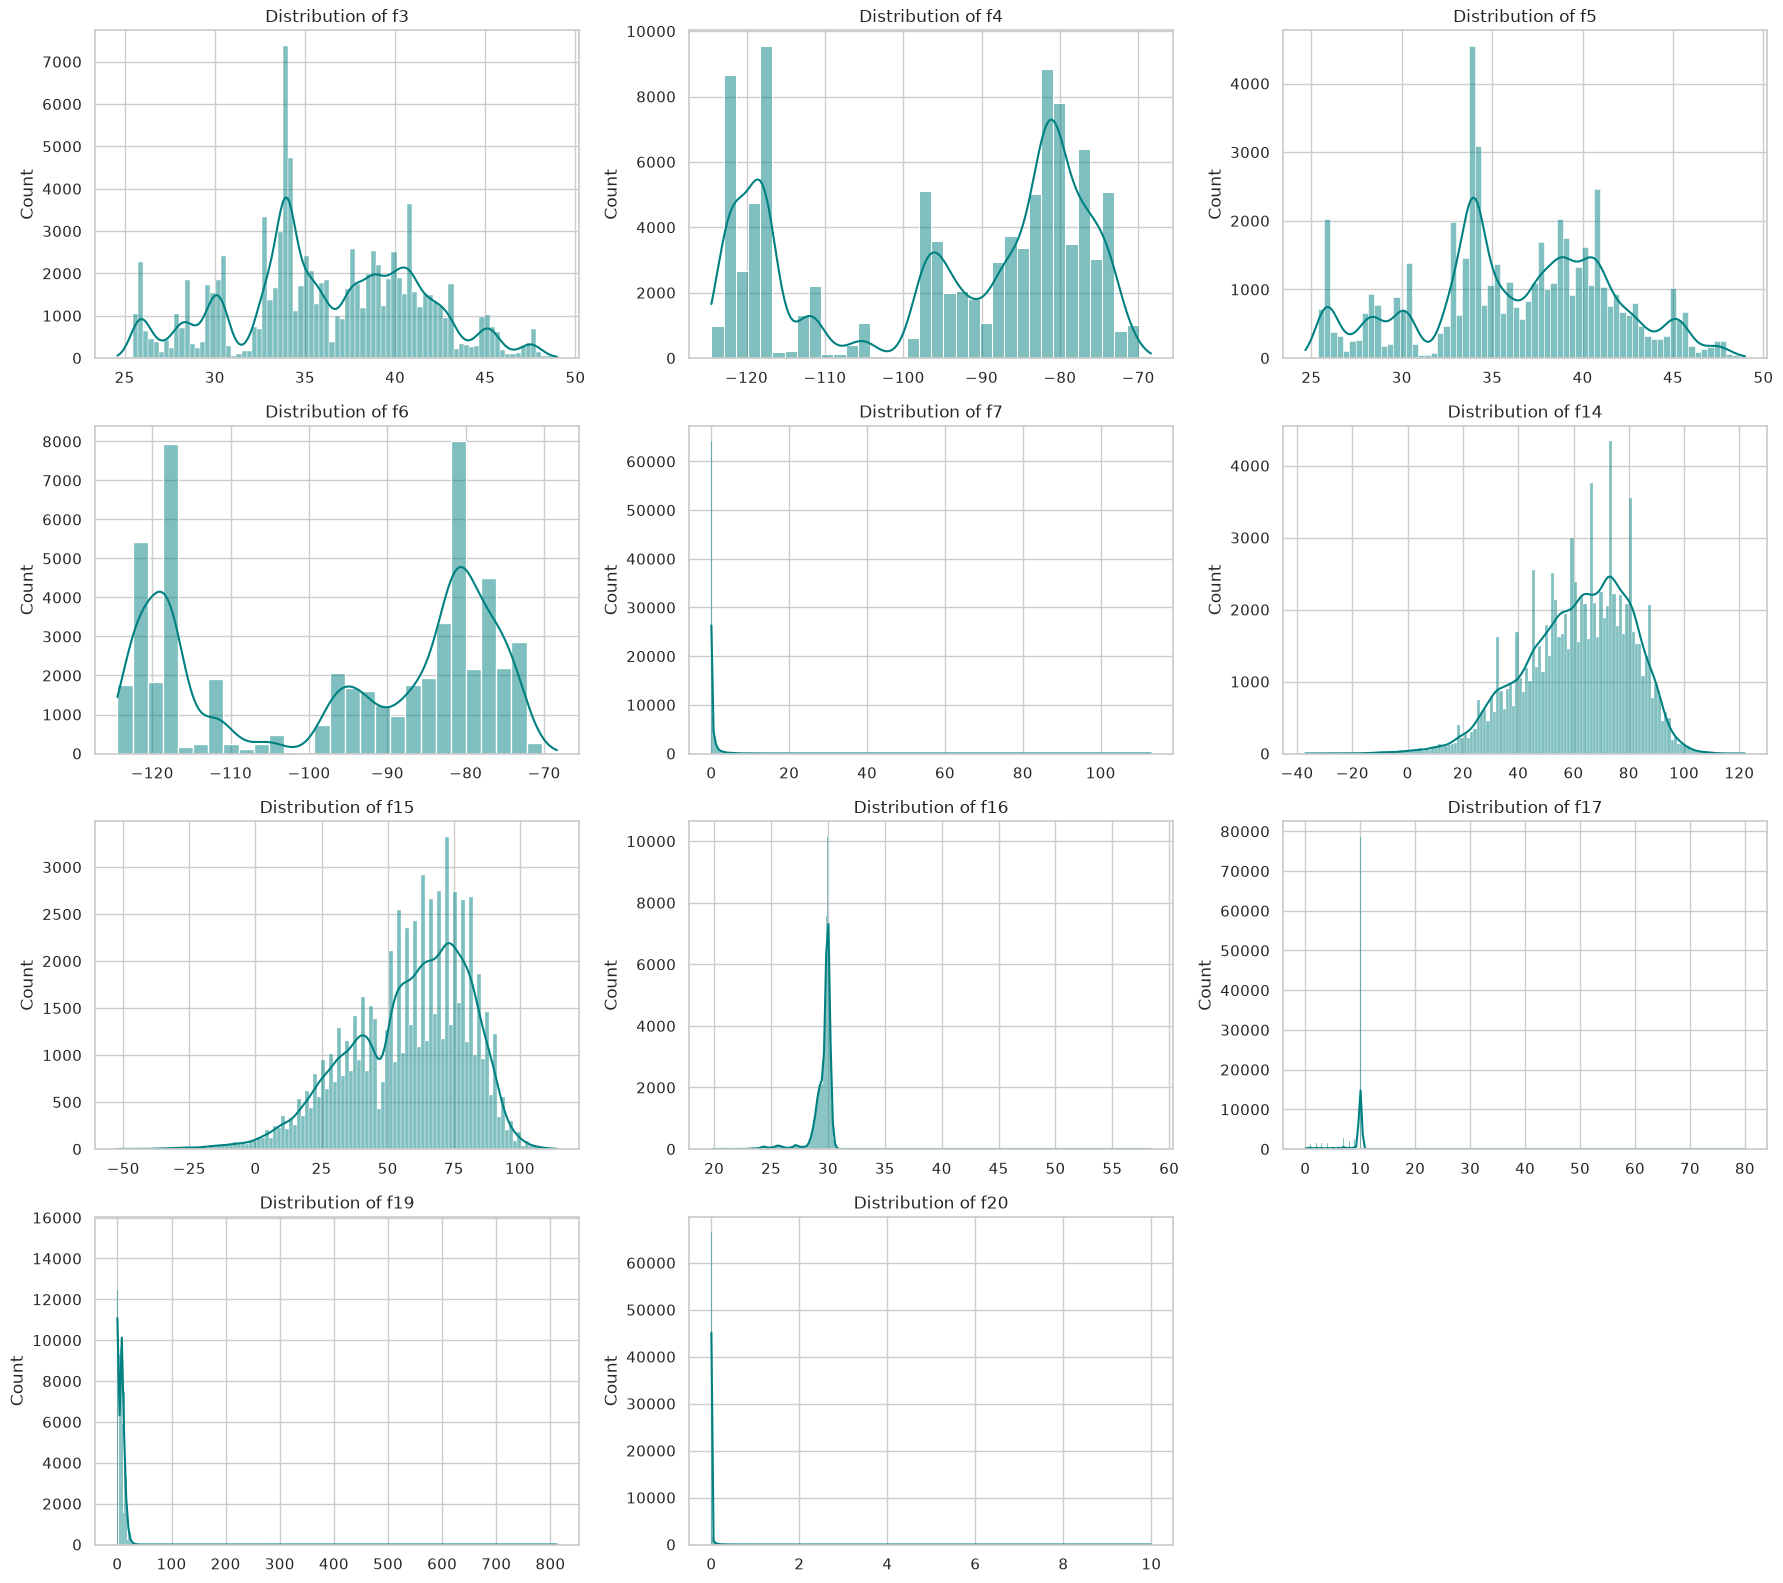

In [22]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
exclude = ['y', 'hour', 'dayofweek', 'month', 'year']
num_cols = [c for c in num_cols if c not in exclude]

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


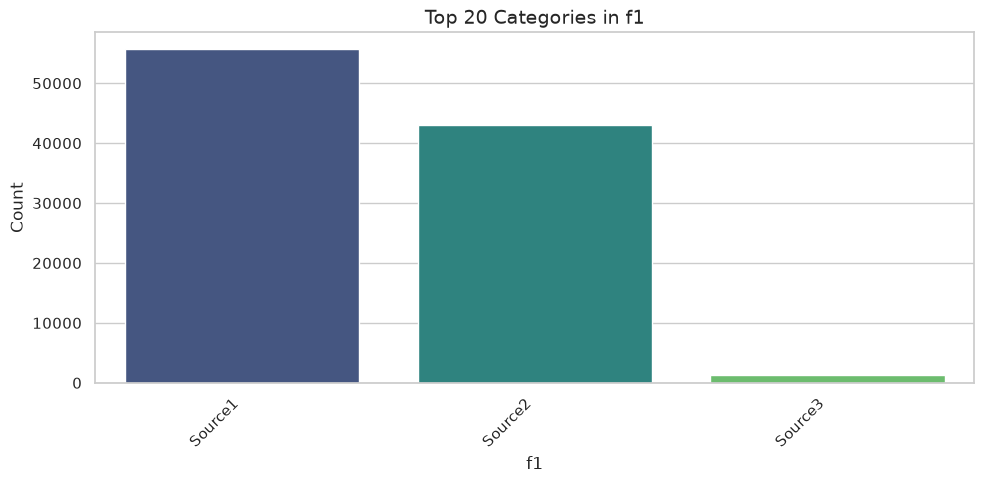

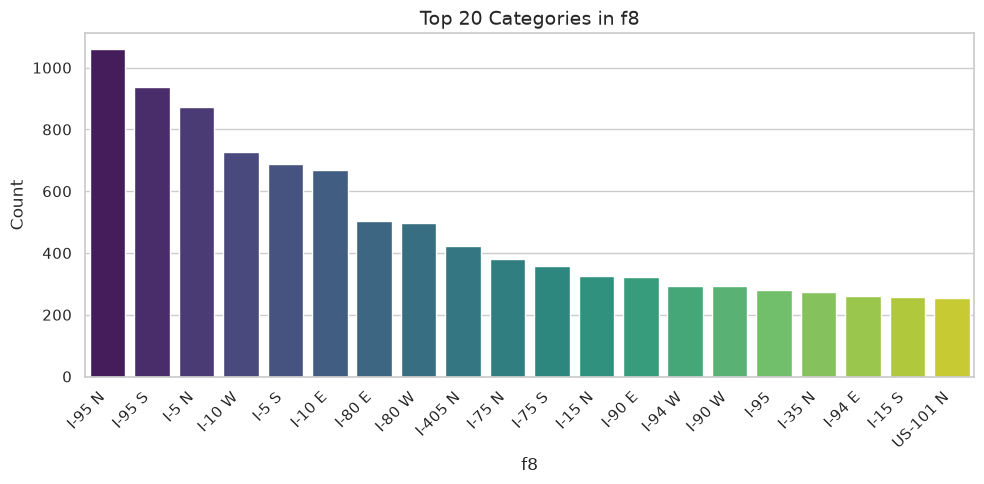

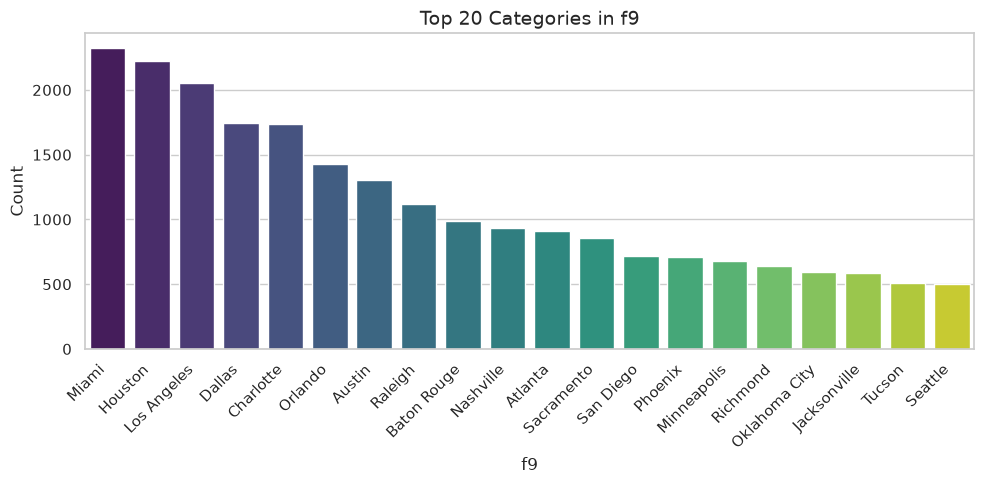

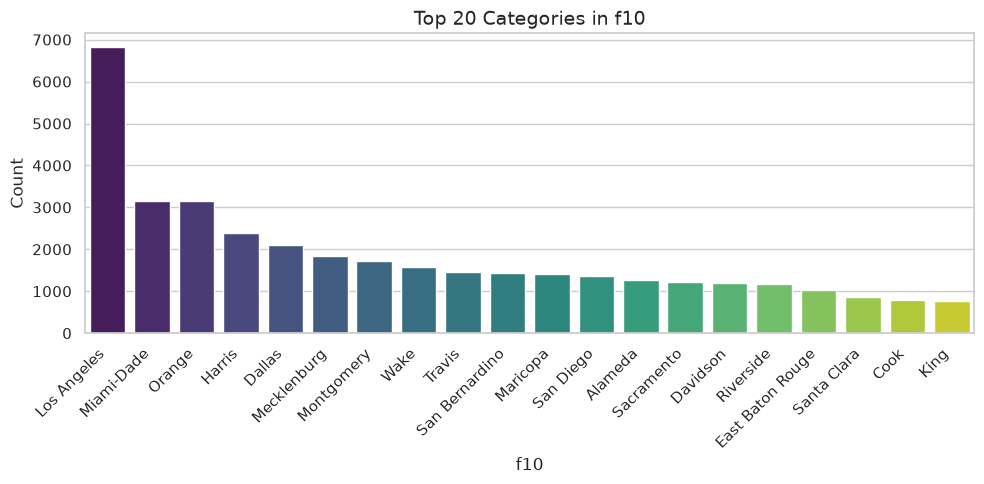

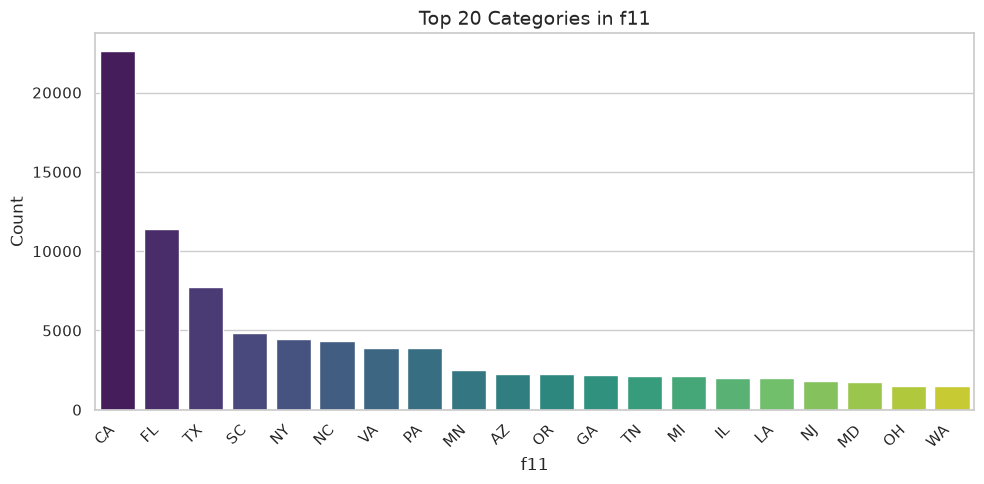

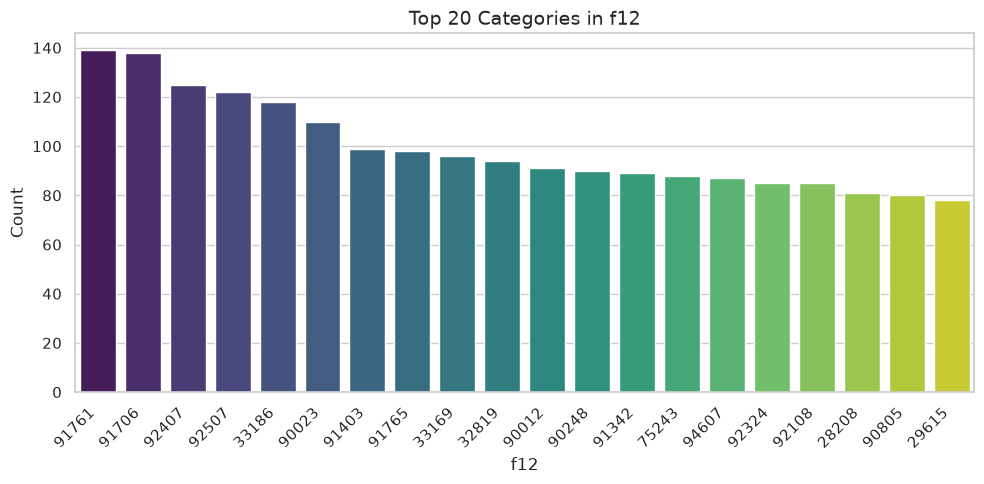

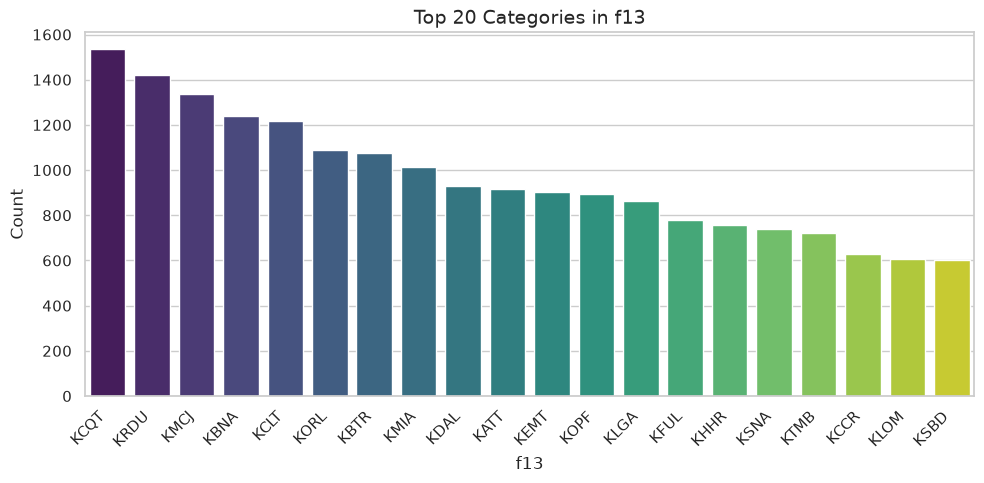

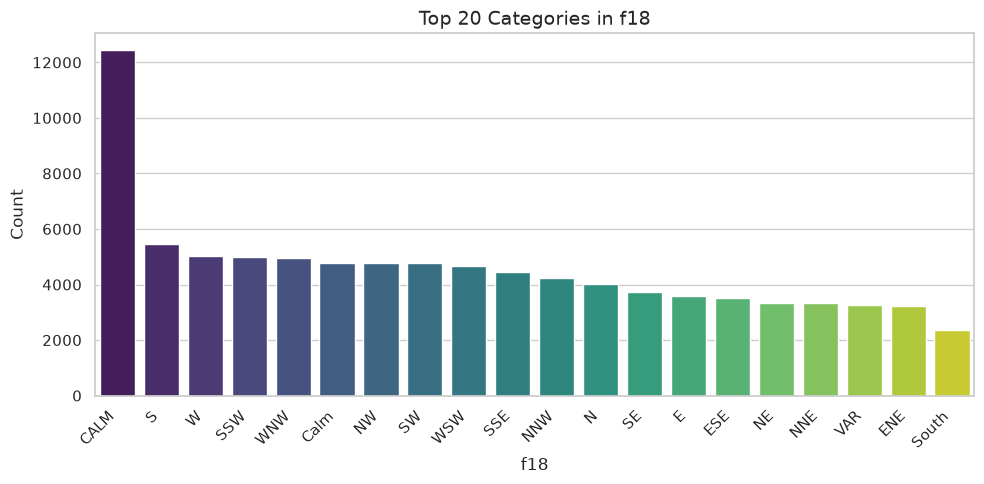

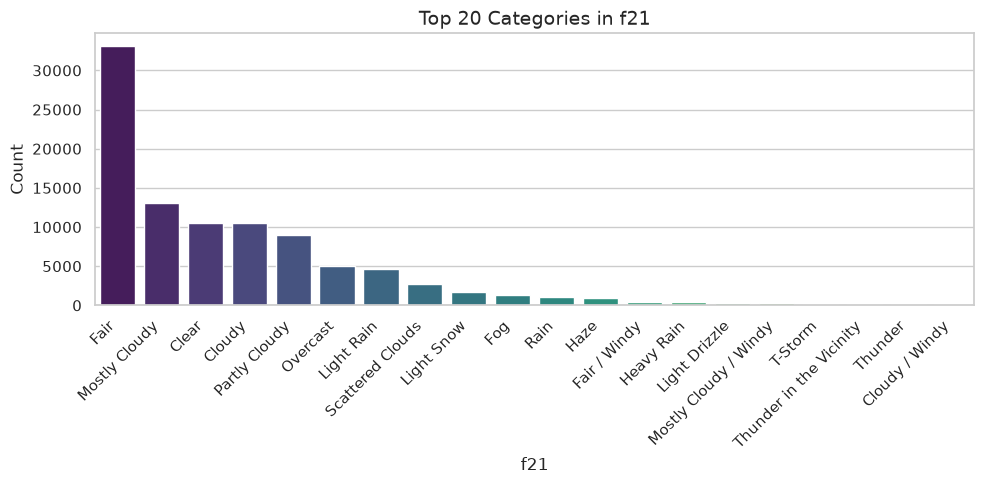

In [23]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'f2']

for col in cat_cols[:10]:
    top_counts = df[col].value_counts().head(20)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_counts.index, y=top_counts.values, palette='viridis')
    plt.title(f'Top 20 Categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Binary columns: ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,true_count,false_count
f22,1234,98766
f23,47,99953
f24,7315,92685
f25,886,99114
f26,3,99997
f27,2919,97081
f28,104,99896
f29,14681,85319
f30,0,100000
f31,31141,68859


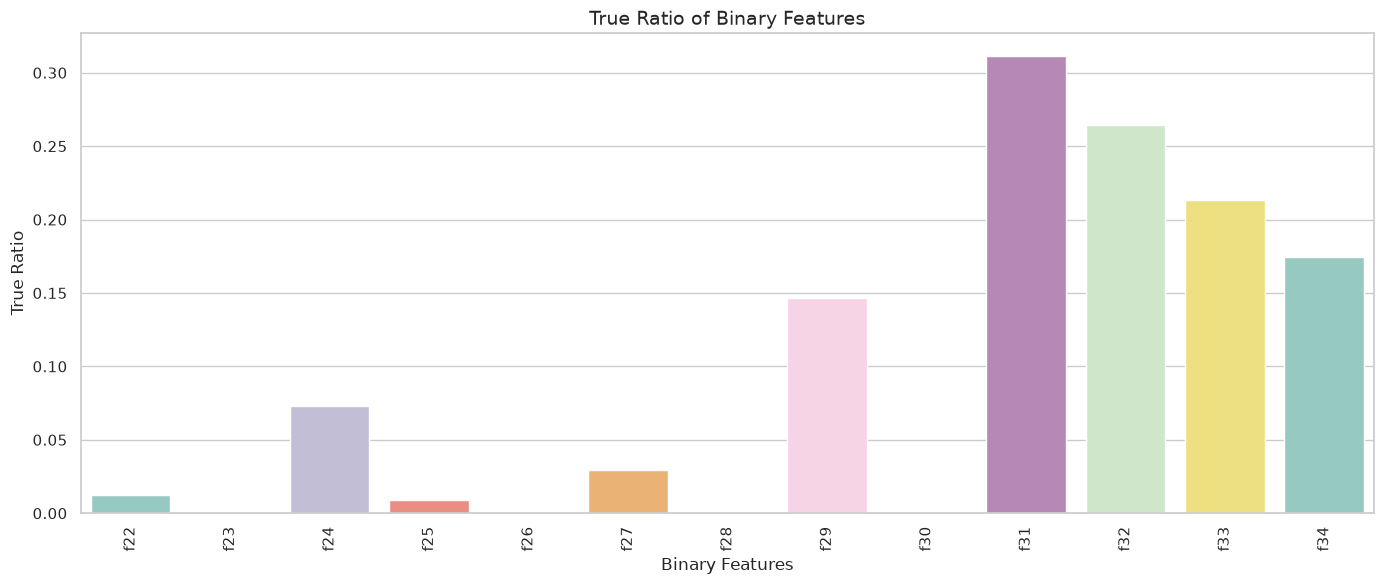

In [24]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]
print('Binary columns:', binary_cols)

binary_summary = pd.DataFrame({
    'true_count': df[binary_cols].sum(numeric_only=True),
    'false_count': df[binary_cols].shape[0] - df[binary_cols].sum(numeric_only=True)
})
display(binary_summary)

binary_summary['true_ratio'] = binary_summary['true_count'] / (binary_summary['true_count'] + binary_summary['false_count'])
plt.figure(figsize=(14, 6))
sns.barplot(x=binary_summary.index, y=binary_summary['true_ratio'], palette='Set3')
plt.xticks(rotation=90)
plt.title('True Ratio of Binary Features')
plt.ylabel('True Ratio')
plt.xlabel('Binary Features')
plt.tight_layout()
plt.show()


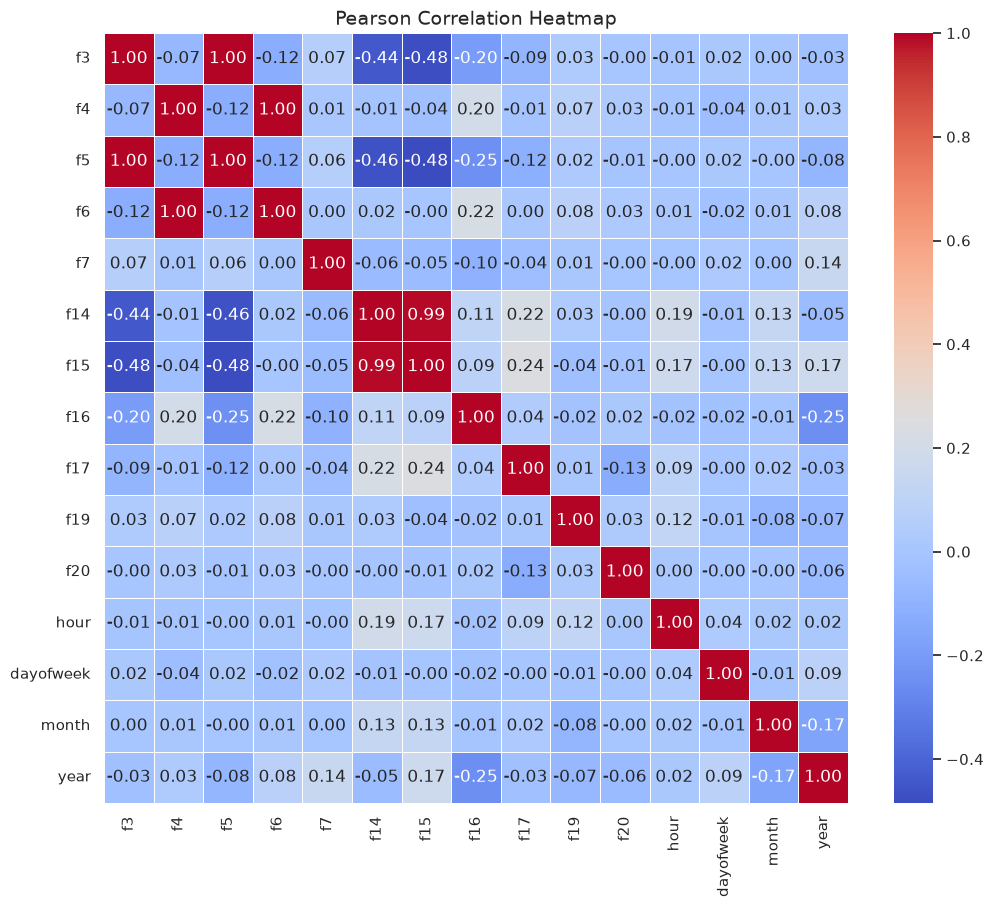

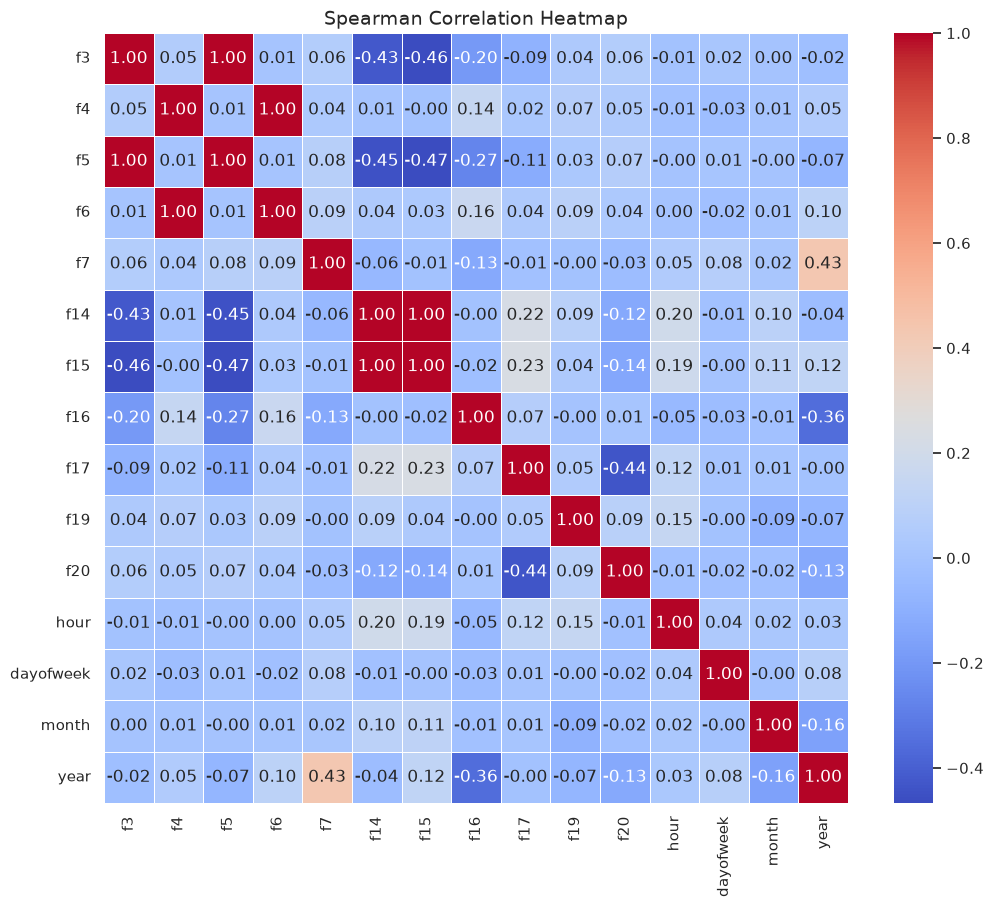

In [25]:
if numeric_cols:
    # Pearson Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Heatmap')
    plt.show()

    # Spearman Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation Heatmap')
    plt.show()
else:
    print("No numerical columns found for correlation analysis.")


Mutual Information Scores (Numerical vs y):
year         0.046359
f6           0.035708
f4           0.035241
f7           0.027112
f5           0.025053
f3           0.024483
month        0.020043
f16          0.006894
f17          0.005608
f19          0.004724
f15          0.002054
f20          0.002032
f14          0.001738
dayofweek    0.001657
hour         0.001242
dtype: float64


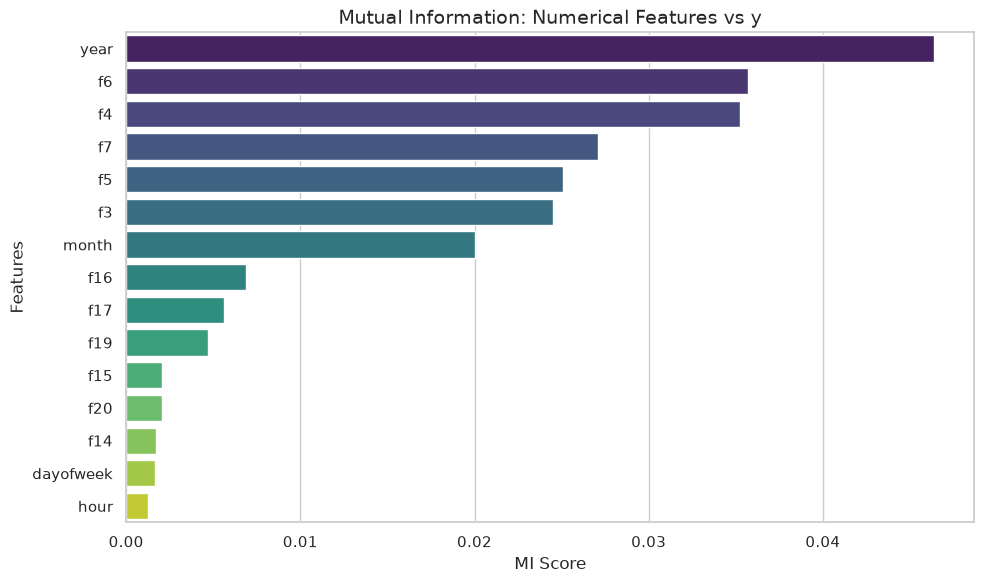

In [26]:


if 'numeric_cols' in locals() and 'y' in df.columns:
    # Data cleaning for MI
    cols_to_use = ['y'] + numeric_cols
    df_mi = df[cols_to_use].dropna()

    if df_mi['y'].nunique() >= 2:
        X_clean = df_mi[numeric_cols]
        y_clean = df_mi['y'].astype(int)

        mi_scores = mutual_info_classif(X_clean, y_clean, random_state=42)
        mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Numerical vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Numerical Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient data: Target 'y' has less than 2 unique classes after dropping NaNs.")
else:
    print("Missing 'numeric_cols' or target 'y' in DataFrame.")


Categorical columns used: ['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21']


,f1,f8,f9,f10,f11,f12,f13,f18,f21
f1,1.000000,0.827379,0.628127,0.383875,0.225348,0.856106,0.432176,0.230635,0.260120
f8,0.827379,1.000000,0.847599,0.869074,0.893715,0.915701,0.859576,0.830592,0.809707
f9,0.628127,0.847599,1.000000,0.925845,0.952914,0.998856,0.896181,0.587862,0.571433
f10,0.383875,0.869074,0.925845,1.000000,0.909489,0.992560,0.840003,0.362221,0.376324
f11,0.225348,0.893715,0.952914,0.909489,1.000000,1.000000,0.972637,0.130461,0.132907
f12,0.856106,0.915701,0.998856,0.992560,1.000000,1.000000,1.000000,0.878915,0.896204
f13,0.432176,0.859576,0.896181,0.840003,0.972637,1.000000,1.000000,0.425852,0.495894
f18,0.230635,0.830592,0.587862,0.362221,0.130461,0.878915,0.425852,1.000000,0.167359
f21,0.260120,0.809707,0.571433,0.376324,0.132907,0.896204,0.495894,0.167359,1.000000


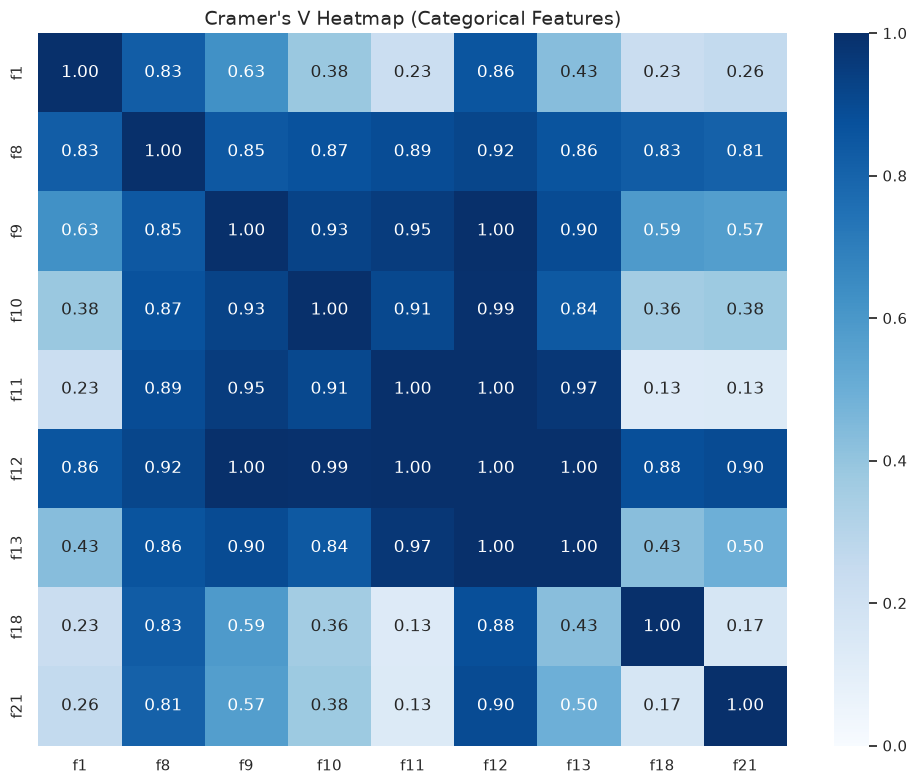

In [27]:


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.empty or confusion_matrix.to_numpy().sum() == 0:
        return np.nan
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    
    if min(r - 1, k - 1) <= 0:
        return 0.0
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

sample_df = df.sample(min(5000, len(df)), random_state=42)
cat_cols = [c for c in sample_df.select_dtypes(include=['object', 'category']).columns if c != 'f2']

print(f"Categorical columns used: {cat_cols}")

cramers_matrix = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)

for i, col1 in enumerate(cat_cols):
    for j, col2 in enumerate(cat_cols):
        if i < j:
            val = cramers_v(sample_df[col1], sample_df[col2])
            cramers_matrix.loc[col1, col2] = val
            cramers_matrix.loc[col2, col1] = val

display(cramers_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f")
plt.title("Cramer's V Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()


Mutual Information Scores (Categorical vs y):
f12    0.123120
f8     0.118652
f1     0.092046
f9     0.070653
f13    0.070353
f10    0.060947
f11    0.030707
f21    0.024279
f18    0.015463
dtype: float64


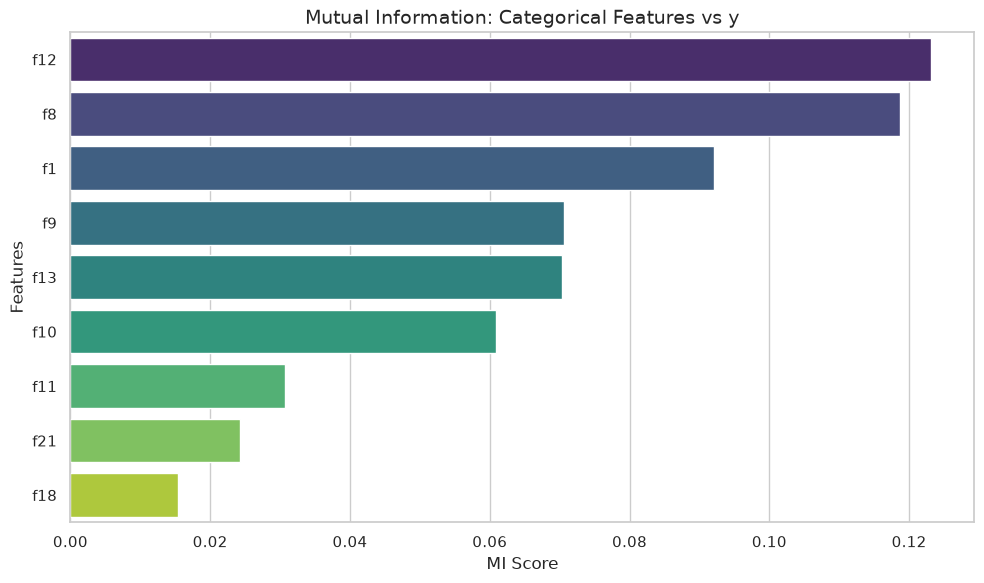

In [28]:


if 'categorical_cols' in locals() and 'y' in df.columns:
    df_clean = df[['y'] + categorical_cols].dropna(subset=['y'])
    
    if df_clean['y'].nunique() >= 2:
        df_encoded = pd.DataFrame()
        for col in categorical_cols:
            df_encoded[col] = df_clean[col].astype('category').cat.codes

        mi_scores = mutual_info_classif(df_encoded, df_clean['y'].astype(int), random_state=42)
        mi_series = pd.Series(mi_scores, index=categorical_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Categorical vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(categorical_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Categorical Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Target 'y' must have at least 2 classes after removing missing values.")
else:
    print("Missing 'categorical_cols' or target 'y' in DataFrame.")


Chi-Square p-values between Boolean Features:


,f22,f23,f24,f25,f26,f27,f28,f29,f31,f32,f33,f34
f22,1.000000e+00,2.240323e-01,1.194573e-15,7.448165e-52,1.000000,3.784781e-17,1.091979e-19,7.130233e-255,1.683043e-03,2.432428e-03,6.723424e-04,3.144355e-03
f23,2.240323e-01,1.000000e+00,2.775051e-01,1.000000e+00,1.000000,6.495944e-10,0.000000e+00,3.224625e-01,1.000000e+00,7.215991e-01,8.647462e-01,3.797496e-01
f24,1.194573e-15,2.775051e-01,1.000000e+00,6.499081e-04,0.004519,3.374887e-31,2.416361e-01,7.502105e-232,2.997873e-01,2.957684e-02,3.870149e-02,1.490628e-02
f25,7.448165e-52,1.000000e+00,6.499081e-04,1.000000e+00,1.000000,1.868685e-04,1.000000e+00,3.449668e-75,1.156284e-01,2.119137e-01,8.999719e-02,9.724579e-02
f26,1.000000e+00,1.000000e+00,4.519479e-03,1.000000e+00,1.000000,1.572065e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
f27,3.784781e-17,6.495944e-10,3.374887e-31,1.868685e-04,0.157207,1.000000e+00,8.352567e-22,1.384509e-58,1.182760e-01,9.620820e-02,3.373618e-01,7.808456e-01
f28,1.091979e-19,0.000000e+00,2.416361e-01,1.000000e+00,1.000000,8.352567e-22,1.000000e+00,1.848487e-03,5.408138e-01,2.669828e-01,1.098011e-01,3.424050e-01
f29,7.130233e-255,3.224625e-01,7.502105e-232,3.449668e-75,1.000000,1.384509e-58,1.848487e-03,1.000000e+00,3.196150e-36,8.501784e-47,3.131893e-48,8.406480e-51
f31,1.683043e-03,1.000000e+00,2.997873e-01,1.156284e-01,1.000000,1.182760e-01,5.408138e-01,3.196150e-36,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
f32,2.432428e-03,7.215991e-01,2.957684e-02,2.119137e-01,1.000000,9.620820e-02,2.669828e-01,8.501784e-47,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00


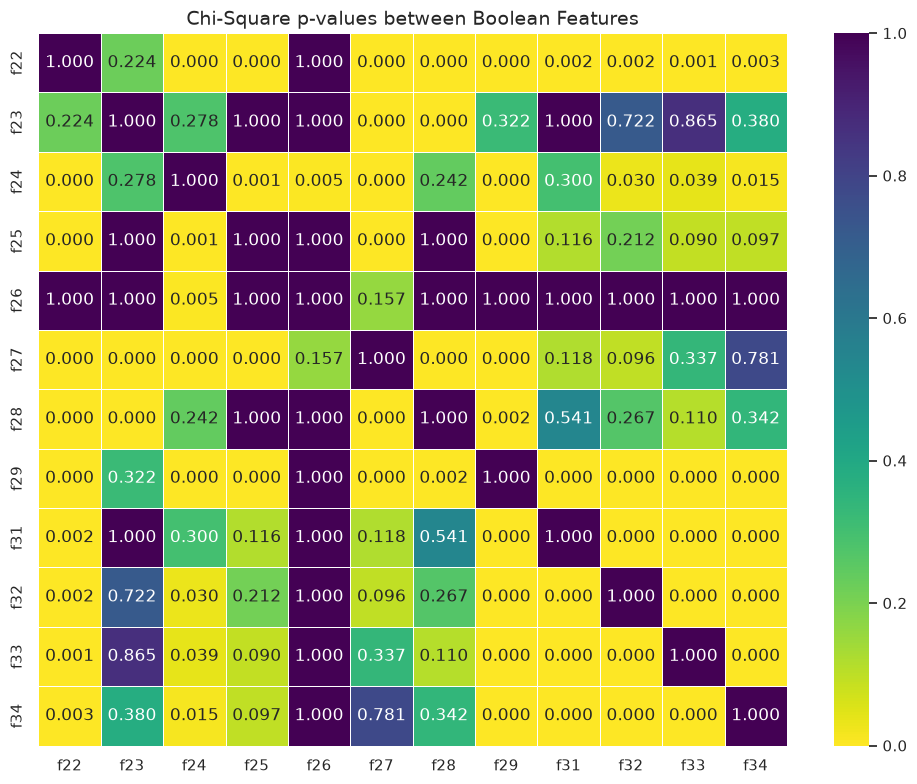

In [29]:
if 'bool_cols' in locals() and len(bool_cols) >= 2:
    valid_bool_cols = [c for c in bool_cols if c in df.columns and df[c].nunique(dropna=True) > 1]

    if len(valid_bool_cols) >= 2:
        pval_matrix = pd.DataFrame(1.0, index=valid_bool_cols, columns=valid_bool_cols)

        for i, col1 in enumerate(valid_bool_cols):
            for col2 in valid_bool_cols[i + 1:]:
                table = pd.crosstab(df[col1], df[col2])

                if table.shape[0] > 1 and table.shape[1] > 1:
                    _, p_val, _, _ = chi2_contingency(table)
                    pval_matrix.loc[col1, col2] = p_val
                    pval_matrix.loc[col2, col1] = p_val

        print("Chi-Square p-values between Boolean Features:")
        display(pval_matrix)

        plt.figure(figsize=(10, 8))
        sns.heatmap(pval_matrix, annot=True, cmap='viridis_r', fmt=".3f", linewidths=.5)
        plt.title('Chi-Square p-values between Boolean Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid boolean columns for Chi-Square test.")
else:
    print("Missing 'bool_cols' or not enough boolean columns.")


Mutual Information Scores (Boolean Features vs y):
f29    0.008877
f31    0.005530
f33    0.004817
f34    0.003389
f27    0.003232
f22    0.002526
f32    0.002233
f23    0.001328
f28    0.000212
f25    0.000159
f24    0.000000
f26    0.000000
f30    0.000000
dtype: float64


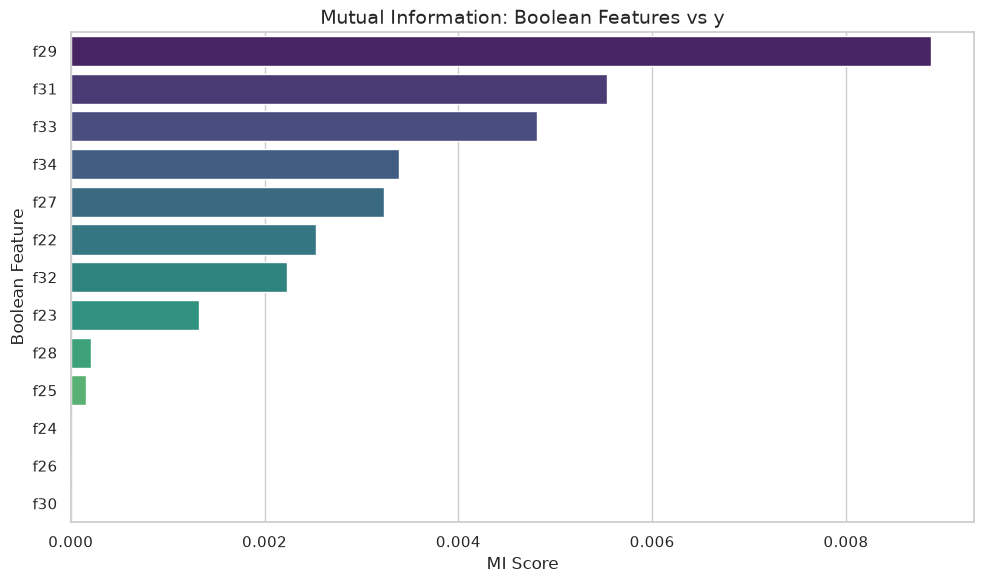

In [30]:

if 'bool_cols' in locals() and bool_cols and 'y' in df.columns:
    valid_bool_cols = [c for c in bool_cols if c in df.columns]

    df_mi = df[valid_bool_cols + ['y']].dropna()
    if df_mi['y'].nunique() >= 2 and valid_bool_cols:
        mi_scores = mutual_info_classif(df_mi[valid_bool_cols], df_mi['y'].astype(int), random_state=42)
        mi_series = pd.Series(mi_scores, index=valid_bool_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Boolean Features vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(valid_bool_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Boolean Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Boolean Feature')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient valid data for Mutual Information analysis.")
elif 'y' not in df.columns:
    print("Missing target column 'y'.")
else:
    print("No boolean columns found.")


In [31]:
original_rows = len(df)

df.drop_duplicates(inplace=True)

print("Removed rows:", original_rows - len(df))
print("New shape:", df.shape)


Removed rows: 136
New shape: (99864, 38)


In [32]:
row_threshold = 0.2

df = df.dropna(thresh=int((1 - row_threshold) * df.shape[1]))

print("Shape after removing highly-missing rows:", df.shape)


Shape after removing highly-missing rows: (99098, 38)


In [33]:
low_nan_cols = [col for col in df.columns if 0 < df[col].isnull().mean() < 0.05]

df.dropna(subset=low_nan_cols, inplace=True)

print("Shape after removing rows with small NaN columns:", df.shape)


Shape after removing rows with small NaN columns: (96417, 38)


In [34]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percent": missing_percent
})

missing_table = missing_table[missing_table["Missing Count"] > 0]

missing_table = missing_table.sort_values("Missing Percent", ascending=False)

missing_table


,Missing Count,Missing Percent
f5,43053,44.652914
f6,43053,44.652914
f20,26584,27.571901
f15,23102,23.960505
f19,4902,5.084166


In [35]:
corr_3_5 = df['f3'].corr(df['f5'])
corr_4_6 = df['f4'].corr(df['f6'])
corr_14_15 = df['f14'].corr(df['f15'])

print(f"Correlation between f3 and f5: {corr_3_5:.4f}")
print(f"Correlation between f4 and f6: {corr_4_6:.4f}")
print(f"Correlation between f14 and f15: {corr_14_15:.4f}")

df.drop(columns=['f5', 'f6', 'f15'], inplace=True)

print("\nColumns 'f5', 'f6', and 'f15' have been dropped.")
print("Current columns in dataframe:", df.columns.tolist())


Correlation between f3 and f5: 1.0000
Correlation between f4 and f6: 1.0000
Correlation between f14 and f15: 0.9938

Columns 'f5', 'f6', and 'f15' have been dropped.
Current columns in dataframe: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [36]:
cols = ['f19', 'f20']

print("Shape:", df[cols].shape)

print("\nMissing values:")
print(df[cols].isna().sum())

print("\nMissing percentage:")
print(df[cols].isna().mean() * 100)

print("\nDescriptive statistics:")
print(df[cols].describe())

print("\nCorrelation:")
print(df[cols].corr())


Shape: (96417, 2)

Missing values:
f19     4902
f20    26584
dtype: int64

Missing percentage:
f19     5.084166
f20    27.571901
dtype: float64

Descriptive statistics:
                f19           f20
count  91515.000000  69833.000000
mean       7.682247      0.007857
std        5.880811      0.087978
min        0.000000      0.000000
25%        4.600000      0.000000
50%        7.000000      0.000000
75%       10.400000      0.000000
max      812.000000      9.990000

Correlation:
          f19       f20
f19  1.000000  0.032516
f20  0.032516  1.000000


In [37]:

X = df[['f19','f20']]
y = df['y']

X = X.fillna(X.median())

mi = mutual_info_classif(X, y)

for col, score in zip(X.columns, mi):
    print(f"{col}: {score}")



f19: 0.027570403037345148
f20: 0.0006925388370266905


In [38]:
df['f19'] = df['f19'].fillna(df['f19'].median())

df.drop(columns=['f20'], inplace=True)

print("f19 missing values filled with median and f20 dropped.")
print("Current columns:", df.columns.tolist())


f19 missing values filled with median and f20 dropped.
Current columns: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 12
['f3', 'f4', 'f7', 'f14', 'f16', 'f17', 'f19', 'y', 'hour', 'dayofweek', 'month', 'year']

Categorical columns: 9
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


In [40]:
df.drop(columns=['f30'], inplace=True)

Feature Engineering Test Results (MI Score):
----------------------------------------
f24                     0.003579
combined_weak_signal    0.000000
f23                     0.000000
f25                     0.000000
f26                     0.000000
f28                     0.000000
dtype: float64
----------------------------------------
Status: NO IMPROVEMENT (Combined 0.000000 <= Single 0.003579)


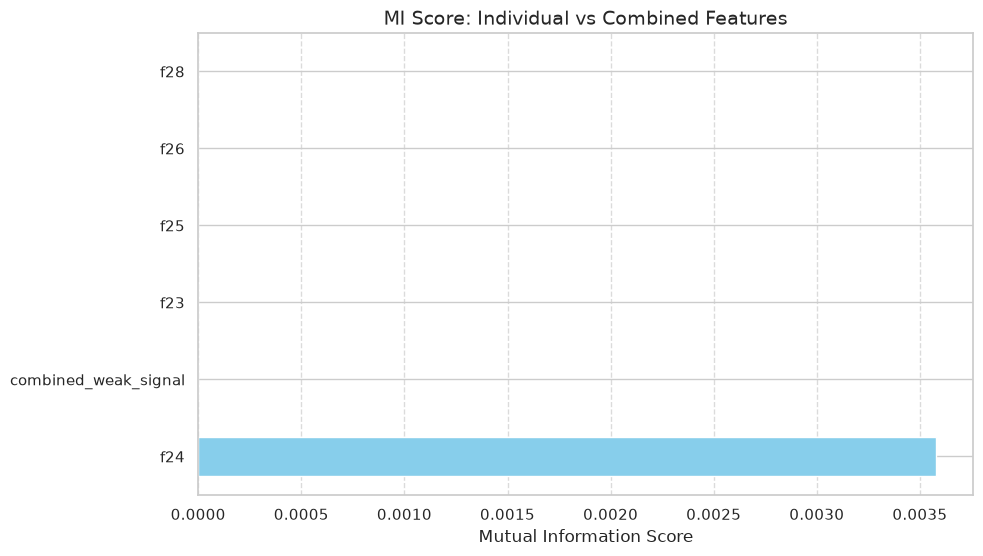

In [41]:

weak_bools = [c for c in ['f23', 'f24', 'f25', 'f26', 'f28'] if c in df.columns]
target_col = 'y'

if weak_bools and target_col in df.columns:
    df_temp = df[weak_bools + [target_col]].dropna()
    
    # Feature Engineering: Sum of weak signals
    df_temp['combined_weak_signal'] = df_temp[weak_bools].sum(axis=1)
    
    X = df_temp[['combined_weak_signal'] + weak_bools]
    y = df_temp[target_col].astype(int)
    
    mi_scores = mutual_info_classif(X, y, random_state=42)
    mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    
    print("Feature Engineering Test Results (MI Score):")
    print("-" * 40)
    print(mi_results)
    
    best_single = mi_results[weak_bools].max()
    combined = mi_results['combined_weak_signal']
    
    print("-" * 40)
    if combined > best_single:
        print(f"Status: SUCCESS (Combined {combined:.6f} > Single {best_single:.6f})")
    else:
        print(f"Status: NO IMPROVEMENT (Combined {combined:.6f} <= Single {best_single:.6f})")

    mi_results.plot(kind='barh', color='skyblue', figsize=(10, 6))
    plt.title("MI Score: Individual vs Combined Features")
    plt.xlabel("Mutual Information Score")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Required columns for feature engineering test are missing.")


In [42]:
df.drop(columns=[c for c in ['f23', 'f24', 'f25', 'f26', 'f28', 'combined_signal'] if c in df.columns], inplace=True)

In [43]:
df.drop(columns=[c for c in ['f8', 'f9', 'f12'] if c in df.columns], inplace=True)

In [44]:
df

,f1,f3,f4,f7,f10,f11,f13,f14,f16,f17,f18,f19,f21,f22,f27,f29,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,0.000,Suffolk,NY,KISP,52.0,29.77,10.0,NNW,13.8,Overcast,False,False,True,False,False,False,False,2,17,4,3,2018
1,Source1,45.358867,-122.762271,1.252,Washington,OR,KUAO,90.0,29.78,10.0,NNE,3.0,Fair,False,False,False,False,False,False,False,2,13,2,7,2022
2,Source1,41.233610,-95.954493,0.585,Douglas,NE,KOMA,76.0,28.67,10.0,VAR,3.0,Mostly Cloudy,False,False,False,False,False,False,False,2,13,0,6,2022
3,Source1,34.039947,-117.505855,0.193,San Bernardino,CA,KONT,77.0,28.89,10.0,WSW,5.0,Fair,False,False,False,True,True,True,True,2,21,1,9,2021
4,Source2,47.230240,-122.448868,0.000,Pierce,WA,KTCM,63.0,29.53,10.0,W,8.0,Cloudy,False,False,False,True,False,False,False,3,20,3,5,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Source2,35.911552,-78.651360,0.000,Wake,NC,KRDU,63.0,29.65,10.0,W,5.0,Partly Cloudy,False,False,True,False,False,False,False,3,16,1,2,2021
99996,Source2,37.770409,-122.406929,0.000,San Francisco,CA,KSFO,56.0,30.29,10.0,CALM,0.0,Fair,True,False,True,False,False,False,False,2,11,2,1,2022
99997,Source2,33.744514,-84.334320,0.000,DeKalb,GA,KATL,54.0,29.23,10.0,NW,10.0,Fair,False,False,False,False,False,False,False,3,19,4,4,2021
99998,Source1,34.081679,-117.731468,1.151,Los Angeles,CA,KPOC,45.0,28.83,1.0,WSW,7.0,Rain,False,False,False,False,False,False,False,2,14,0,12,2020


In [45]:
cat_cols = ['f1', 'f10', 'f11', 'f13', 'f18', 'f21']

summary = []

for col in cat_cols:
    temp = df[[col, 'y']].dropna()
    vc = temp[col].value_counts()
    
    summary.append({
        'column': col,
        'unique_count': temp[col].nunique(),
        'missing_count': df[col].isna().sum(),
        'missing_percent': df[col].isna().mean() * 100,
        'top_value': vc.index[0],
        'top_count': vc.iloc[0],
        'top_percent': vc.iloc[0] / len(temp) * 100,
        'rare_count_lt_10': (vc < 10).sum(),
        'rare_count_lt_50': (vc < 50).sum(),
        'rare_count_lt_100': (vc < 100).sum()
    })

summary_df = pd.DataFrame(summary).sort_values('unique_count', ascending=False)
display(summary_df)


,column,unique_count,missing_count,missing_percent,top_value,top_count,top_percent,rare_count_lt_10,rare_count_lt_50,rare_count_lt_100
3,f13,1588,0,0.0,KCQT,1494,1.549519,734,1175,1337
1,f10,1279,0,0.0,Los Angeles,6528,6.770590,678,1006,1102
5,f21,80,0,0.0,Fair,32468,33.674559,30,47,53
2,f11,49,0,0.0,CA,21757,22.565523,1,5,5
4,f18,24,0,0.0,CALM,12233,12.687597,0,0,0
0,f1,3,0,0.0,Source1,53364,55.347086,0,0,0


In [46]:
cat_cols = ['f1', 'f10', 'f11', 'f13', 'f18', 'f21']

for col in cat_cols:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Total feature count: {len(df.columns)}")


Final shape: (96417, 25)
Columns: ['f1', 'f3', 'f4', 'f7', 'f10', 'f11', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f21', 'f22', 'f27', 'f29', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']
Total feature count: 25


In [47]:
df

,f1,f3,f4,f7,f10,f11,f13,f14,f16,f17,f18,f19,f21,f22,f27,f29,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,0.433668,40.810566,-73.256042,0.000,0.005155,0.044971,0.001452,52.0,29.77,10.0,0.043633,13.8,0.051817,False,False,True,False,False,False,False,2,17,4,3,2018
1,0.553471,45.358867,-122.762271,1.252,0.005092,0.022631,0.001504,90.0,29.78,10.0,0.034091,3.0,0.336746,False,False,False,False,False,False,False,2,13,2,7,2022
2,0.553471,41.233610,-95.954493,0.585,0.005041,0.003879,0.001037,76.0,28.67,10.0,0.033542,3.0,0.134603,False,False,False,False,False,False,False,2,13,0,6,2022
3,0.553471,34.039947,-117.505855,0.193,0.014022,0.225655,0.004771,77.0,28.89,10.0,0.047730,5.0,0.336746,False,False,False,True,True,True,True,2,21,1,9,2021
4,0.433668,47.230240,-122.448868,0.000,0.002178,0.015340,0.001193,63.0,29.53,10.0,0.051485,8.0,0.106900,False,False,False,True,False,False,False,3,20,3,5,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.433668,35.911552,-78.651360,0.000,0.016149,0.044028,0.014603,63.0,29.65,10.0,0.051485,5.0,0.092152,False,False,True,False,False,False,False,3,16,1,2,2021
99996,0.433668,37.770409,-122.406929,0.000,0.002199,0.225655,0.002863,56.0,30.29,10.0,0.126876,0.0,0.336746,True,False,True,False,False,False,False,2,11,2,1,2022
99997,0.433668,33.744514,-84.334320,0.000,0.003060,0.021718,0.004947,54.0,29.23,10.0,0.048944,10.0,0.336746,False,False,False,False,False,False,False,3,19,4,4,2021
99998,0.553471,34.081679,-117.731468,1.151,0.067706,0.225655,0.005290,45.0,28.83,1.0,0.047730,7.0,0.010589,False,False,False,False,False,False,False,2,14,0,12,2020


In [48]:
extreme_skewed = ['f19', 'f7'] 
if 'f20' in df.columns: extreme_skewed.append('f20')

for col in extreme_skewed:
    df[col] = np.log1p(df[col])

numeric_cols = ['f3', 'f4', 'f7', 'f14', 'f16', 'f17', 'f19', 'hour', 'dayofweek', 'month', 'year']
if 'f20' in df.columns: numeric_cols.append('f20')

scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Preprocessing Complete. Ready for Training.")


Preprocessing Complete. Ready for Training.


In [49]:
df

,f1,f3,f4,f7,f10,f11,f13,f14,f16,f17,f18,f19,f21,f22,f27,f29,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,0.433668,0.744497,0.397870,-0.065486,0.005155,0.044971,0.001452,-0.444444,-0.121212,0.0,0.043633,0.911212,0.051817,False,False,True,False,False,False,False,2,0.444444,0.333333,-0.571429,-0.50
1,0.553471,1.417949,-0.945520,2.087504,0.005092,0.022631,0.001504,0.962963,-0.106061,0.0,0.034091,-1.026689,0.336746,False,False,False,False,False,False,False,2,0.000000,-0.333333,0.000000,0.50
2,0.553471,0.807135,-0.218070,1.156010,0.005041,0.003879,0.001037,0.444444,-1.787879,0.0,0.033542,-1.026689,0.134603,False,False,False,False,False,False,False,2,0.000000,-1.000000,-0.142857,0.50
3,0.553471,-0.258007,-0.802883,0.402525,0.014022,0.225655,0.004771,0.481481,-1.454545,0.0,0.047730,-0.426114,0.336746,False,False,False,True,True,True,True,2,0.888889,-0.666667,0.285714,0.25
4,0.433668,1.695037,-0.937015,-0.065486,0.002178,0.015340,0.001193,-0.037037,-0.484848,0.0,0.051485,0.174460,0.106900,False,False,False,True,False,False,False,3,0.777778,0.000000,-0.285714,-0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.433668,0.019115,0.251464,-0.065486,0.016149,0.044028,0.014603,-0.037037,-0.303030,0.0,0.051485,-0.426114,0.092152,False,False,True,False,False,False,False,3,0.333333,-0.666667,-0.714286,0.25
99996,0.433668,0.294350,-0.935877,-0.065486,0.002199,0.225655,0.002863,-0.296296,0.666667,0.0,0.126876,-3.080067,0.336746,True,False,True,False,False,False,False,2,-0.222222,-0.333333,-0.857143,0.50
99997,0.433668,-0.301751,0.097252,-0.065486,0.003060,0.021718,0.004947,-0.370370,-0.939394,0.0,0.048944,0.471693,0.336746,False,False,False,False,False,False,False,3,0.666667,0.333333,-0.428571,0.25
99998,0.553471,-0.251828,-0.809005,1.965812,0.067706,0.225655,0.005290,-0.703704,-1.545455,-9.0,0.047730,0.000000,0.010589,False,False,False,False,False,False,False,2,0.111111,-1.000000,0.714286,0.00


In [50]:
X = df.drop(columns=['y'])
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")
print("\n--- Class Proportion in Train vs Test ---")
print("Train:\n", y_train.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))


Train size: 77133 rows
Test size: 19284 rows

--- Class Proportion in Train vs Test ---
Train:
 y
2    0.795911
3    0.169435
4    0.026085
1    0.008570
Name: proportion, dtype: float64

Test:
 y
2    0.795893
3    0.169467
4    0.026084
1    0.008556
Name: proportion, dtype: float64
